In [1]:
import pandas as pd
df = pd.read_excel("Excel_Test.xlsx")
df.shape

(1755, 10)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1755 entries, 0 to 1754
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   User ID                    1755 non-null   str           
 1   Customer first Order Date  1755 non-null   datetime64[us]
 2   Nation                     1755 non-null   str           
 3   Product Name               1755 non-null   str           
 4   order number               1755 non-null   str           
 5   Payment Method             1755 non-null   str           
 6   Order Status               1755 non-null   str           
 7   Order value                1755 non-null   float64       
 8   Order Reqquest Date        1755 non-null   str           
 9   Order Success Date         1755 non-null   str           
dtypes: datetime64[us](1), float64(1), str(8)
memory usage: 137.2 KB


In [3]:
df.describe()

,Customer first Order Date,Order value
count,1755,1755.000000
mean,2024-12-09 21:48:15.900854,5899.776068
min,2023-04-08 17:11:13,5.000000
25%,2024-05-11 21:17:01,1000.000000
50%,2025-02-18 01:11:55,2000.000000
75%,2025-09-01 11:43:47,5000.000000
max,2025-12-01 23:16:27,55000.000000
std,NaN,9915.959073


In [4]:
for col in ['Nation', 'Product Name','order number','Payment Method','Order Status']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Nation ---
Nation
India     1715
Others      30
Japan        3
Brazil       2
Canada       2
Mexico       1
UK           1
Poland       1
Name: count, dtype: int64

--- Product Name ---
Product Name
Pro Hub 811             2
Aero Gadget 610         2
Dynamic Hub 233         2
Digital Receiver 574    1
Quantum Engine 485      1
                       ..
Prime Frame 772         1
Cyber Device 989        1
Aero Module 366         1
Meta System 316         1
Ultra Set 828           1
Name: count, Length: 1752, dtype: int64

--- order number ---
order number
J176460472104106000049241    1
J176460465113736001225285    1
J176460459163606000610303    1
J176460454014276001785211    1
J176460449592236001248850    1
                            ..
J176451844002176002034427    1
J176451843649476002094613    1
J176451842383896001935061    1
J176451842132796011203895    1
J176451842129516001568147    1
Name: count, Length: 1755, dtype: int64

--- Payment Method ---
Payment Method
Paypal         

In [7]:
df['Order Reqquest Date'] = pd.to_datetime(df['Order Reqquest Date'])
df['Order Success Date'] = pd.to_datetime(df['Order Success Date'])
df.dtypes

User ID                                 str
Customer first Order Date    datetime64[us]
Nation                                  str
Product Name                            str
order number                            str
Payment Method                          str
Order Status                            str
Order value                         float64
Order Reqquest Date          datetime64[us]
Order Success Date           datetime64[us]
dtype: object

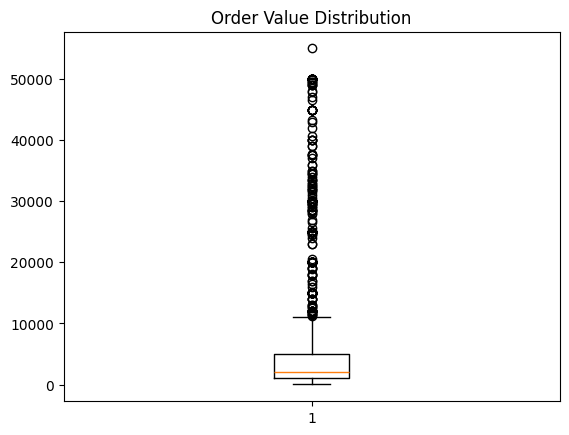

In [9]:
import matplotlib.pyplot as plt

plt.boxplot(df['Order value'])
plt.title('Order Value Distribution')
plt.show()

In [11]:
Q1 = df['Order value'].quantile(0.25)
Q3 = df['Order value'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Order value'] < Q1 - 1.5 * IQR) | (df['Order value'] > Q3 + 1.5 * IQR)]
outliers

,User ID,Customer first Order Date,Nation,Product Name,order number,Payment Method,Order Status,Order value,Order Reqquest Date,Order Success Date
5,600****863,2025-06-01 13:27:53,India,Pro Device 718,J176460446968456002070863,Paypal,success,47900.0,2025-12-01 23:54:29,2025-12-01 23:56:00
9,600****990,2025-09-01 02:07:30,India,Prime Panel 577,J176460436737916006208990,Paypal,success,12000.0,2025-12-01 23:52:47,2025-12-01 23:54:00
18,601****290,2025-11-20 21:58:25,India,Prime Pad 658,J176460387988396011143290,Crypto,failure,30000.0,2025-12-01 23:44:39,2000-01-01 08:00:00
24,600****863,2025-06-01 13:27:53,India,Hyper Receiver 298,J176460368971026002070863,Paypal,success,42000.0,2025-12-01 23:41:29,2025-12-01 23:46:30
32,600****863,2025-06-01 13:27:53,India,Fusion Controller 312,J176460344923986002070863,Paypal,success,50000.0,2025-12-01 23:37:29,2025-12-01 23:39:00
...,...,...,...,...,...,...,...,...,...,...
1691,601****953,2025-12-01 00:21:54,India,Opti System 915,J176451973683886011203953,Paypal,failure,29000.0,2025-12-01 00:22:16,2000-01-01 08:00:00
1699,600****863,2025-06-01 13:27:53,India,Nano Gadget 640,J176451946857176002070863,Paypal,success,31000.0,2025-12-01 00:17:48,2025-12-01 00:18:57
1721,600****953,2023-10-05 09:27:21,India,Turbo Box 504,J176451902136586000611953,Paypal,success,14000.0,2025-12-01 00:10:21,2025-12-01 00:11:44
1731,601****819,2025-11-30 23:27:43,India,Fusion Gadget 277,J176451879033766011203819,GooglePay,failure,50000.0,2025-12-01 00:06:30,2000-01-01 08:00:00


In [12]:
print(outliers[['Order value', 'Nation', 'Payment Method', 'Order Status']].head(20))

     Order value Nation Payment Method Order Status
5        47900.0  India         Paypal      success
9        12000.0  India         Paypal      success
18       30000.0  India         Crypto      failure
24       42000.0  India         Paypal      success
32       50000.0  India         Paypal      success
52       28500.0  India         Paypal      success
53       55000.0  India   VIP transfer      success
59       23000.0  India         Paypal      success
61       28561.0  India         Paypal      failure
64       50000.0  India         Paypal      failure
72       15000.0  India         Paypal      failure
83       30500.0  India         Paypal      success
90       32500.0  India         Paypal      failure
100      33500.0  India         Paypal      failure
107      46500.0  India         Paypal      failure
123      29500.0  India         Paypal      success
127      34500.0  India         Paypal      failure
139      15000.0  India         Crypto      success
140      295

In [13]:
nation_revenue = df.groupby('Nation')['Order value'].sum().sort_values(ascending=False)
print(nation_revenue)

Nation
India     10136000.0
Others      217396.0
Japan          290.0
Canada         259.0
Brazil         110.0
Poland          20.0
UK              20.0
Mexico          12.0
Name: Order value, dtype: float64


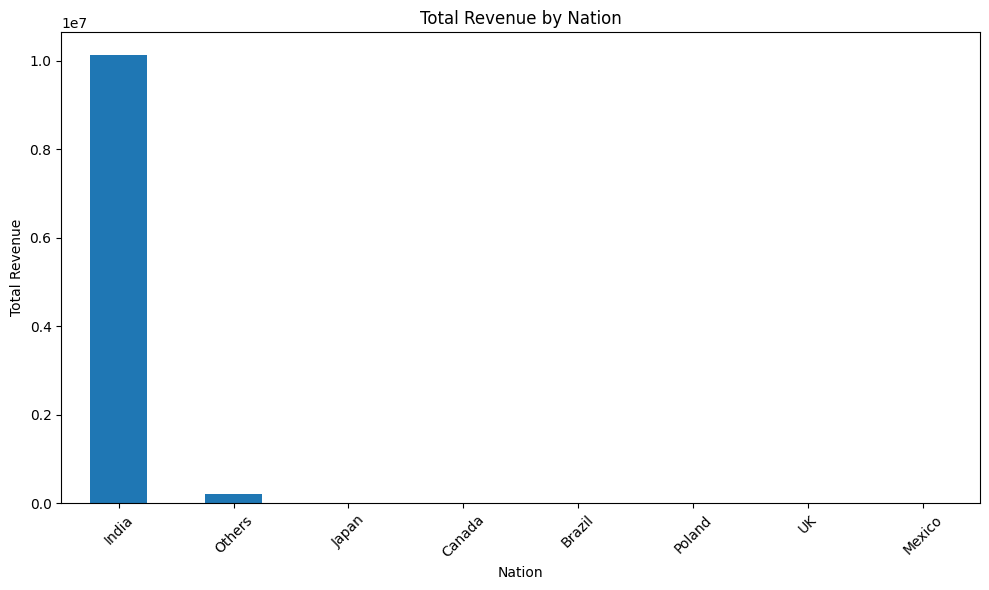

In [14]:
nation_revenue.plot(kind='bar', figsize=(10, 6), title='Total Revenue by Nation')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()

In [16]:
payment_status = df.groupby([('Payment Method') , 'Order Status']).size().unstack()

print(payment_status)

Order Status    failure  success
Payment Method                  
Cash               30.0     39.0
Crypto            325.0    154.0
GooglePay          91.0     48.0
Master Card         7.0      NaN
Paypal            435.0    619.0
VIP transfer        NaN      5.0
VISA                NaN      2.0


In [17]:
payment_status['success_rate'] = (payment_status['success']/(payment_status['success'] + payment_status['failure']) * 100).round(1)

print(payment_status[['success_rate']])

Order Status    success_rate
Payment Method              
Cash                    56.5
Crypto                  32.2
GooglePay               34.5
Master Card              NaN
Paypal                  58.7
VIP transfer             NaN
VISA                     NaN


In [20]:
product_revenue = df.groupby('Product Name')['Order value'].sum().sort_values(ascending = False)
print(product_revenue.head(10))

Product Name
Max Controller 402    55000.0
Smart Set 956         50000.0
Quantum Tool 592      50000.0
Super Gadget 320      50000.0
Aero Module 783       50000.0
Super Panel 210       50000.0
Eco Receiver 689      50000.0
Quantum Pad 169       50000.0
Nano Accessory 177    50000.0
Hyper Panel 486       50000.0
Name: Order value, dtype: float64


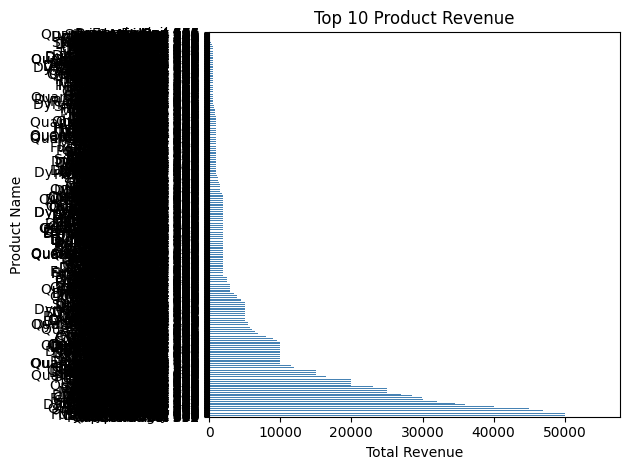

In [23]:
product_revenue.plot(kind='barh', title='Top 10 Product Revenue', color='steelblue')
plt.xlabel('Total Revenue')
plt.tight_layout()
plt.show()

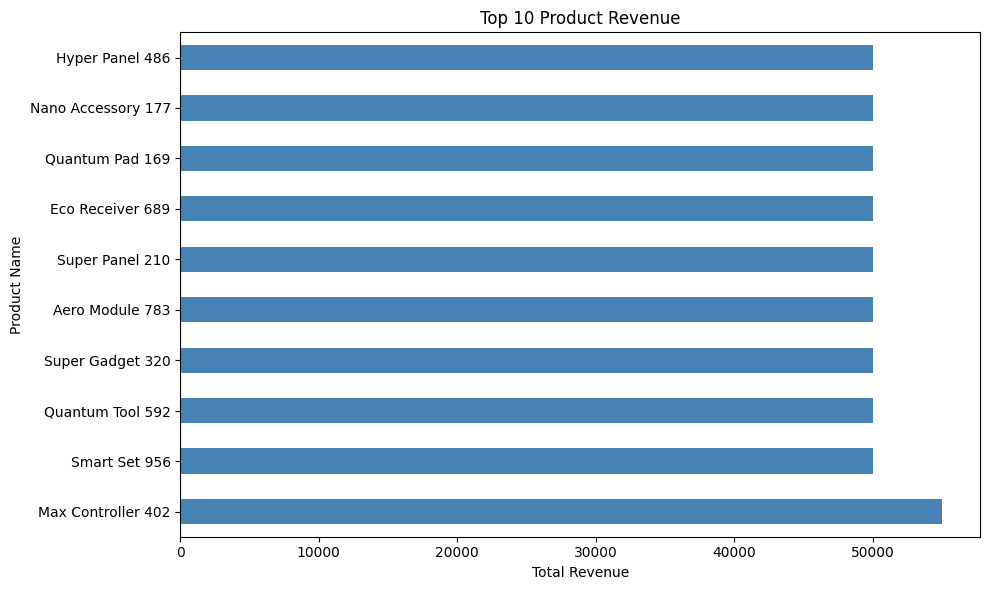

In [24]:
top10 = df.groupby('Product Name')['Order value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top10.plot(kind='barh', color='steelblue')
plt.title('Top 10 Product Revenue')
plt.xlabel('Total Revenue')
plt.tight_layout()
plt.show()

In [28]:
df['Month'] = df['Customer first Order Date'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Order value'].sum()

monthly_revenue

Month
2023-04      96772.0
2023-05     141930.0
2023-06      19000.0
2023-07      24000.0
2023-08      86000.0
2023-09     148336.0
2023-10     275500.0
2023-11     144200.0
2023-12      57705.0
2024-01      35600.0
2024-02      78100.0
2024-03     205811.0
2024-04     234370.0
2024-05     192735.0
2024-06     303199.0
2024-07     478999.0
2024-08     107264.0
2024-09      95199.0
2024-10     112197.0
2024-11     171691.0
2024-12      21080.0
2025-01     247700.0
2025-02      93127.0
2025-03     117008.0
2025-04    1094991.0
2025-05     342784.0
2025-06    1535180.0
2025-07     171505.0
2025-08     733825.0
2025-09     466166.0
2025-10     242238.0
2025-11    1634207.0
2025-12     645688.0
Freq: M, Name: Order value, dtype: float64

NameError: name 't' is not defined

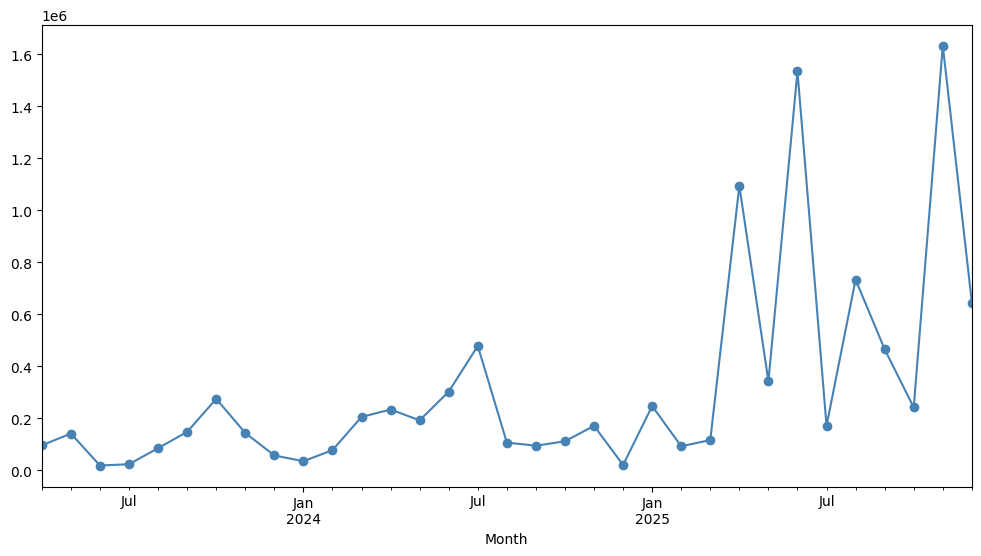

In [29]:
plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', color = 'steelblue', marker='o')
t.title('Monthly Revenue Trend')
t.ylabel('Total Revenue')
t.xticks(rotation=45)
t.tight_layout()
t.show()

In [32]:
df['success_num'] = (df['Order Status'] == 'success').astype(int)
monthly_success = df.groupby('Month')['success_num'].mean() * 100
monthly_success

Month
2023-04     34.426230
2023-05     48.780488
2023-06     80.000000
2023-07    100.000000
2023-08     66.666667
2023-09     52.307692
2023-10     67.924528
2023-11     52.631579
2023-12     77.777778
2024-01     71.428571
2024-02     70.000000
2024-03     51.785714
2024-04     69.642857
2024-05     51.851852
2024-06     45.238095
2024-07     39.705882
2024-08     55.172414
2024-09     43.478261
2024-10     52.631579
2024-11     39.534884
2024-12     61.538462
2025-01     62.222222
2025-02     45.000000
2025-03     60.000000
2025-04     30.476190
2025-05     72.463768
2025-06     48.000000
2025-07     59.322034
2025-08     48.314607
2025-09     30.588235
2025-10     42.857143
2025-11     51.658768
2025-12     45.882353
Freq: M, Name: success_num, dtype: float64

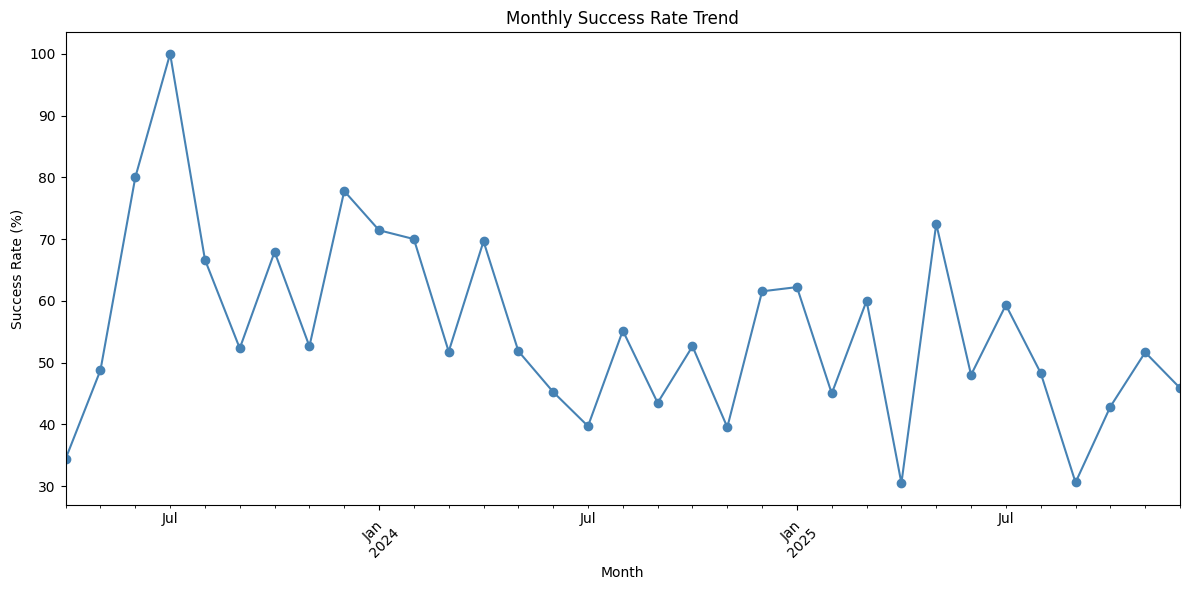

In [33]:
plt.figure(figsize=(12, 6))
monthly_success.plot(kind='line', color='steelblue', marker='o')
plt.title('Monthly Success Rate Trend')
plt.ylabel('Success Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

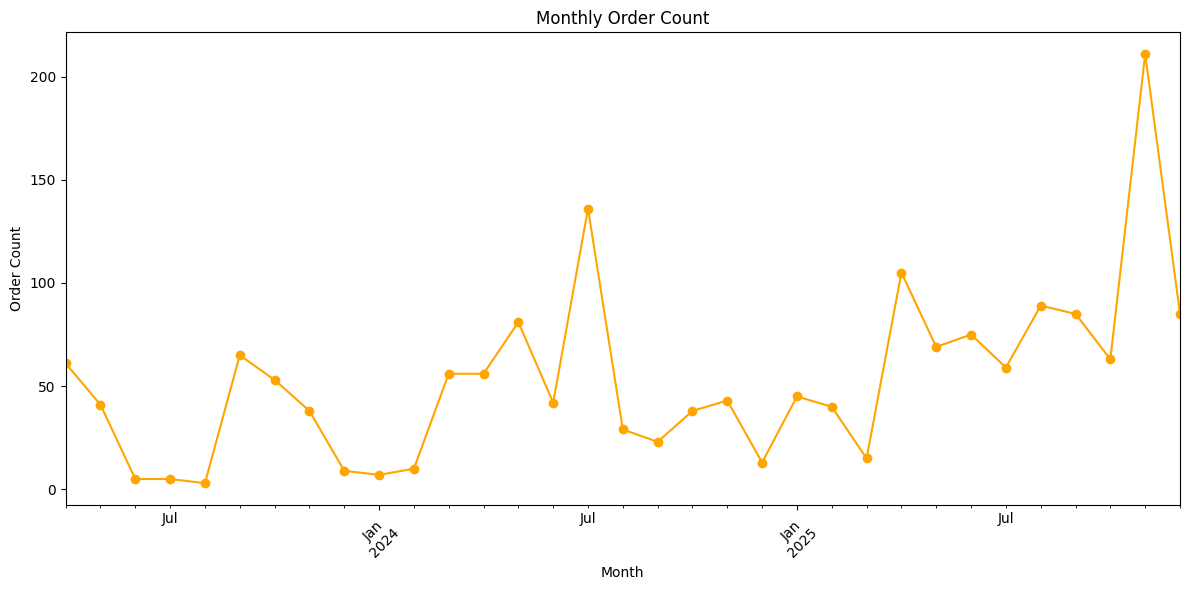

In [35]:
monthly_orders = df.groupby('Month')['order number'].count()

plt.figure(figsize=(12, 6))
monthly_orders.plot(kind='line', color='orange', marker='o')
plt.title('Monthly Order Count')
plt.ylabel('Order Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
print("=" * 50)
print("E-COMMERCE ORDER DATA ANALYSIS REPORT")
print("=" * 50)

print("\n📊 OVERVIEW")
print(f"Total Orders     : {len(df):,}")
print(f"Total Revenue    : {df['Order value'].sum():,.0f}")
print(f"Average Order    : {df['Order value'].mean():,.0f}")
print(f"Median Order     : {df['Order value'].median():,.0f}")

print("\n🌍 TOP NATION")
print(df.groupby('Nation')['Order value'].sum().sort_values(ascending=False).head(3))

print("\n💳 PAYMENT METHOD SUCCESS RATE")
payment_status = df.groupby(['Payment Method', 'Order Status']).size().unstack()
payment_status['success_rate'] = (payment_status['success'] / 
                                   (payment_status['success'] + payment_status['failure']) * 100).round(1)
print(payment_status['success_rate'])

print("\n✅ OVERALL SUCCESS RATE")
print(f"{(df['Order Status'] == 'success').mean() * 100:.1f}%")

print("\n⚠️ OUTLIERS")
Q1 = df['Order value'].quantile(0.25)
Q3 = df['Order value'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Order value'] < Q1 - 1.5*IQR) | (df['Order value'] > Q3 + 1.5*IQR)]
print(f"High Value Orders : {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)")

E-COMMERCE ORDER DATA ANALYSIS REPORT

📊 OVERVIEW
Total Orders     : 1,755
Total Revenue    : 10,354,107
Average Order    : 5,900
Median Order     : 2,000

🌍 TOP NATION
Nation
India     10136000.0
Others      217396.0
Japan          290.0
Name: Order value, dtype: float64

💳 PAYMENT METHOD SUCCESS RATE
Payment Method
Cash            56.5
Crypto          32.2
GooglePay       34.5
Master Card      NaN
Paypal          58.7
VIP transfer     NaN
VISA             NaN
Name: success_rate, dtype: float64

✅ OVERALL SUCCESS RATE
49.4%

⚠️ OUTLIERS
High Value Orders : 236 rows (13.4%)


In [37]:
nation_success = df.groupby('Nation')['success_num'].mean() * 100
nation_success = nation_success.round(1).sort_values(ascending=False)
print(nation_success)

Nation
Canada    100.0
UK        100.0
Poland    100.0
Mexico    100.0
Japan      66.7
Others     63.3
Brazil     50.0
India      49.0
Name: success_num, dtype: float64


In [38]:
india_df = df[df['Nation'] == 'India']
india_payment = india_df.groupby(['Payment Method', 'Order Status']).size().unstack()
india_payment['success_rate'] = (india_payment['success'] / 
                                  (india_payment['success'] + india_payment['failure']) * 100).round(1)
print(india_payment['success_rate'])

Payment Method
Cash            39.0
Crypto          32.2
GooglePay       34.5
Master Card      NaN
Paypal          59.1
VIP transfer     NaN
Name: success_rate, dtype: float64


In [39]:
print(india_df['Payment Method'].value_counts())

Payment Method
Paypal          1044
Crypto           479
GooglePay        139
Cash              41
Master Card        7
VIP transfer       5
Name: count, dtype: int64


In [40]:
print("=" * 55)
print("   E-COMMERCE ORDER DATA ANALYSIS REPORT")
print("=" * 55)

print("\n📊 OVERVIEW")
print(f"  Total Orders     : {len(df):,}")
print(f"  Total Revenue    : {df['Order value'].sum():,.0f}")
print(f"  Average Order    : {df['Order value'].mean():,.0f}")
print(f"  Median Order     : {df['Order value'].median():,.0f}")
print(f"  Overall Success  : {(df['Order Status'] == 'success').mean()*100:.1f}%")

print("\n🌍 NATION ANALYSIS")
nation_rev = df.groupby('Nation')['Order value'].sum().sort_values(ascending=False)
for nation, rev in nation_rev.items():
    pct = rev / df['Order value'].sum() * 100
    print(f"  {nation:<10} Revenue: {rev:>12,.0f}  ({pct:.1f}%)")

print("\n💳 PAYMENT METHOD SUCCESS RATE")
payment_status = df.groupby(['Payment Method', 'Order Status']).size().unstack()
payment_status['success_rate'] = (payment_status['success'] /
                                   (payment_status['success'] + payment_status['failure']) * 100).round(1)
payment_count = df['Payment Method'].value_counts()
for method in payment_status.index:
    rate = payment_status.loc[method, 'success_rate']
    count = payment_count.get(method, 0)
    rate_str = f"{rate:.1f}%" if str(rate) != 'nan' else "N/A"
    print(f"  {method:<15} Orders: {count:>4}   Success Rate: {rate_str}")

print("\n⚠️ OUTLIERS (High Value Orders)")
Q1 = df['Order value'].quantile(0.25)
Q3 = df['Order value'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Order value'] < Q1 - 1.5*IQR) |
              (df['Order value'] > Q3 + 1.5*IQR)]
print(f"  High Value Orders : {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)")
print(f"  Min Outlier Value : {outliers['Order value'].min():,.0f}")
print(f"  Max Outlier Value : {outliers['Order value'].max():,.0f}")

print("\n🔍 ROOT CAUSE — LOW SUCCESS RATE")
print("  India (97% of orders) Payment Analysis:")
india_df = df[df['Nation'] == 'India']
india_payment = india_df.groupby(['Payment Method', 'Order Status']).size().unstack()
india_payment['success_rate'] = (india_payment['success'] /
                                  (india_payment['success'] + india_payment['failure']) * 100).round(1)
payment_count_india = india_df['Payment Method'].value_counts()
for method in india_payment.index:
    rate = india_payment.loc[method, 'success_rate']
    count = payment_count_india.get(method, 0)
    rate_str = f"{rate:.1f}%" if str(rate) != 'nan' else "N/A"
    print(f"  {method:<15} Orders: {count:>4}   Success Rate: {rate_str}")

print("\n💡 RECOMMENDATIONS")
print("  1. Investigate Crypto payment processing  (479 orders, 32.2% success)")
print("  2. Fix GooglePay integration              (139 orders, 34.5% success)")
print("  3. Promote Paypal usage                   (best success rate 59.1%)")
print("  4. Focus on India market improvement      (97% of total revenue)")

print("\n" + "=" * 55)
print("   END OF REPORT")
print("=" * 55)

   E-COMMERCE ORDER DATA ANALYSIS REPORT

📊 OVERVIEW
  Total Orders     : 1,755
  Total Revenue    : 10,354,107
  Average Order    : 5,900
  Median Order     : 2,000
  Overall Success  : 49.4%

🌍 NATION ANALYSIS
  India      Revenue:   10,136,000  (97.9%)
  Others     Revenue:      217,396  (2.1%)
  Japan      Revenue:          290  (0.0%)
  Canada     Revenue:          259  (0.0%)
  Brazil     Revenue:          110  (0.0%)
  Poland     Revenue:           20  (0.0%)
  UK         Revenue:           20  (0.0%)
  Mexico     Revenue:           12  (0.0%)

💳 PAYMENT METHOD SUCCESS RATE
  Cash            Orders:   69   Success Rate: 56.5%
  Crypto          Orders:  479   Success Rate: 32.2%
  GooglePay       Orders:  139   Success Rate: 34.5%
  Master Card     Orders:    7   Success Rate: N/A
  Paypal          Orders: 1054   Success Rate: 58.7%
  VIP transfer    Orders:    5   Success Rate: N/A
  VISA            Orders:    2   Success Rate: N/A

⚠️ OUTLIERS (High Value Orders)
  High Value O